<div style="text-align:center;">
  <img src="https://github.com/MolSSI-Education/iqb-2025/blob/main/images/molssi_main_outline.png?raw=true\" style="display: block; margin: 0 auto; max-height:200px;">
</div>



Examining and Visualizing Data
=============================

<strong>Author(s):</strong> Jessica A. Nash, The Molecular Sciences Software Institute

<div class="alert alert-block alert-info">
<h2>Overview</h2>

<strong>Questions:</strong>

* How can I use pandas to process data?

* How can I visualize relationships between different parts of my data?

<strong>Objectives:</strong>

* Use pandas and seaborn to load and explore data

</div>

[Pandas](https://pandas.pydata.org/docs/) is a Python library used for data analysis and manipulation. Within the world of data science, it is a ubiquitous and widely used library. If you are learning how to analyze data in Python, it will be almost impossible to avoid pandas.

The central data structure of pandas is called a DataFrame. Pandas DataFrames work very closely with NumPy arrays and Pandas dataframes are specifically for data which is two dimensional (rows and columns). NumPy arrays, while similar in some ways, can work with higher dimensional data.

Pandas is very powerful. In this session, we'll be learning how to access information in pandas dataframes and how to do some basic manipulation and analysis. We are going to be looking at a dataset which gives information about the elements in the periodic table.

In [1]:
!pip install pandas seaborn matplotlib rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 16.4 MB/s eta 0:00:00


## Pandas Dataframes

In this notebook, we will load from a comma separate file (.csv - kind of a simplified version of a spreadsheet) into a pandas dataframe, which is a two-dimensional array of data in rows and columns. In this notebooks we will take advantage of some of the features that are native to pandas dataframes for data analysis and plotting.

In [2]:
import pandas as pd

from urllib.request import urlretrieve
url = ("https://raw.githubusercontent.com/MolSSI-Education/molssicheminfo/refs/heads/master/data/PubChemElements_all.csv")
filename = "PubChemElements_all.csv"
urlretrieve(url, filename)

df = pd.read_csv(filename)
df

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,114,Fl,Flerovium,289.191000,NaN,[Rn]7s2 7p2 5f14 6d10 (predicted),NaN,180.0,NaN,NaN,NaN,Expected to be a Solid,NaN,NaN,NaN,Post-transition metal,1998
114,115,Mc,Moscovium,290.196000,NaN,[Rn]7s2 7p3 5f14 6d10 (predicted),NaN,187.0,NaN,NaN,NaN,Expected to be a Solid,NaN,NaN,NaN,Post-transition metal,2003
115,116,Lv,Livermorium,293.205000,NaN,[Rn]7s2 7p4 5f14 6d10 (predicted),NaN,183.0,NaN,NaN,NaN,Expected to be a Solid,NaN,NaN,NaN,Post-transition metal,2000
116,117,Ts,Tennessine,294.211000,NaN,[Rn]7s2 7p5 5f14 6d10 (predicted),NaN,138.0,NaN,NaN,NaN,Expected to be a Solid,NaN,NaN,NaN,Halogen,2010


## Examining Data

Initially when loading data in, and also at certain points as we're working with it, we'll want to see what our dataframe looks like. You can see a preview of your dataframe using the `.head` function

In [3]:
df.head()         # This command will display the first five rows of the dataframe. Click the variable record on the left {x} to learn more about this dataframe.

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808


The `.info` function will give information about the columns and the data type of those columns. The data type will become very important later as we work with data more.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AtomicNumber           118 non-null    int64  
 1   Symbol                 118 non-null    object 
 2   Name                   118 non-null    object 
 3   AtomicMass             118 non-null    float64
 4   CPKHexColor            108 non-null    object 
 5   ElectronConfiguration  118 non-null    object 
 6   Electronegativity      95 non-null     float64
 7   AtomicRadius           113 non-null    float64
 8   IonizationEnergy       102 non-null    float64
 9   ElectronAffinity       57 non-null     float64
 10  OxidationStates        103 non-null    object 
 11  StandardState          118 non-null    object 
 12  MeltingPoint           103 non-null    float64
 13  BoilingPoint           93 non-null     float64
 14  Density                96 non-null     float64
 15  GroupB

For this dataframe, we see that the first column, `AtomicNumber` has the data type of `int64`. Here, `int` means `integer` and `64` means `64 bit`.  The `64 bit` refers to the amount of computer memory the variable can occupy. It won't really be important for us. Similarly, `float64` means `64 bit floating point`. These are decimal numbers.

The other column names which read `object` are not numeric. They might be strings or they might be something else. We'll discuss more later.

The `describe` function can be used on a dataframe to quickly see statistics about columns with numerical data. If you look at the columns that statistics are computed for and compare to the data type shown from `info`, you will see that we only get statistics for columns which had `int64` or `float64` data types.

In [5]:
df.describe()

,AtomicNumber,AtomicMass,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,MeltingPoint,BoilingPoint,Density
count,118.000000,118.000000,95.000000,113.000000,102.000000,57.000000,103.000000,93.000000,96.000000
mean,59.500000,146.607635,1.732316,201.902655,7.997255,1.072140,1273.740553,2536.212473,7.608001
std,34.207699,89.845304,0.635187,42.025707,3.339066,0.879163,888.853859,1588.410919,5.878692
min,1.000000,1.008000,0.700000,120.000000,3.894000,0.079000,0.950000,4.220000,0.000090
25%,30.250000,66.480000,1.290000,180.000000,6.020500,0.470000,516.040000,1180.000000,2.572500
50%,59.500000,142.573850,1.620000,202.000000,6.960000,0.754000,1191.000000,2792.000000,7.072000
75%,88.750000,226.777165,2.170000,229.000000,8.998500,1.350000,1806.500000,3618.000000,10.275250
max,118.000000,294.214000,3.980000,348.000000,24.587000,3.617000,3823.000000,5869.000000,22.570000


This information is extremely useful for understanding the data. We can also easily visualize the distribution of each column using Pandas's ``hist`` function.

array([[<Axes: title={'center': 'AtomicNumber'}>,
        <Axes: title={'center': 'AtomicMass'}>,
        <Axes: title={'center': 'Electronegativity'}>],
       [<Axes: title={'center': 'AtomicRadius'}>,
        <Axes: title={'center': 'IonizationEnergy'}>,
        <Axes: title={'center': 'ElectronAffinity'}>],
       [<Axes: title={'center': 'MeltingPoint'}>,
        <Axes: title={'center': 'BoilingPoint'}>,
        <Axes: title={'center': 'Density'}>]], dtype=object)

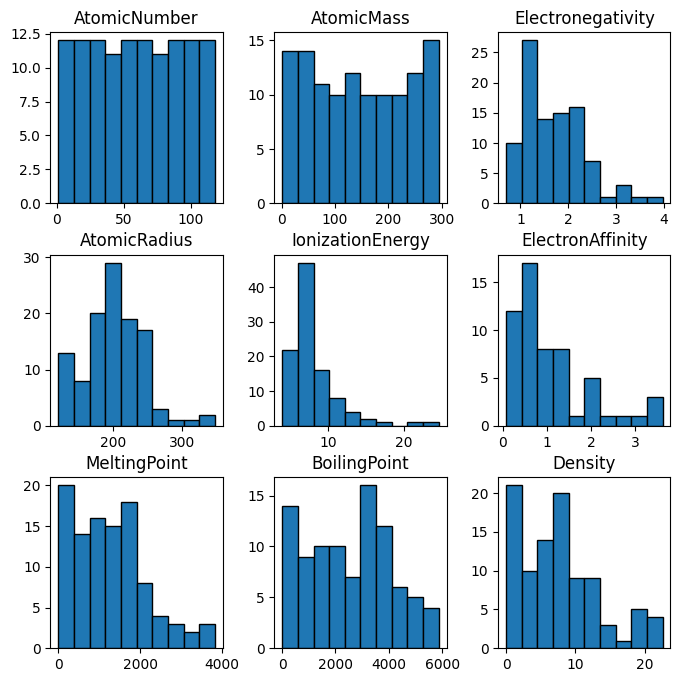

In [6]:
df.hist(figsize=(8,8), edgecolor='black', grid=False)

## Accessing Data

Pandas dataframes have names for rows (called the "index" in Pandas) and columns.

Pandas dataframes have rows and columns, you can see how many rows and columns using `.shape`. This will return the shape as `(num_rows, num_columns)`.

In [7]:
df.shape

(118, 17)

There are a few methods for accessing information in a Pandas dataframe, but the one that will be most important in this workshop is selecting particular columns of data.

In [8]:
df["AtomicNumber"].head()          # You can select one column by putting the column header in the square brackets. The header is a string, so it must be in quotes.

,AtomicNumber
0,1
1,2
2,3
3,4
4,5


In [9]:
df[["Symbol", "ElectronConfiguration"]].head()           # To select multiple columns, put list in brackets

,Symbol,ElectronConfiguration
0,H,1s1
1,He,1s2
2,Li,[He]2s1
3,Be,[He]2s2
4,B,[He]2s2 2p1


## Performing calculations with pandas: No more `for` loops!

Both pandas and NumPy dataframes have the convenient feature that they can do element-wise operations and use something called `broadcasting`. This means that if you are doing something like subtracting a number, multiplying, etc to a column or dataframe of information, it can be done all at once instead of with a `for` loop. Consider if we wanted to calculate the melting point in degrees celsius for all of the elements.

Instead of writing a `for` loop that does this, we can just write the following code. This will return a pandas Series (one dimensional dataframe).

In [10]:
df['MeltingPoint'] - 273.15

,MeltingPoint
0,-259.34
1,-272.20
2,180.50
3,1286.85
4,2074.85
...,...
113,NaN
114,NaN
115,NaN
116,NaN


We could do this one two columns as well.

In [11]:
df[['MeltingPoint', 'BoilingPoint']] - 273.15

,MeltingPoint,BoilingPoint
0,-259.34,-252.87
1,-272.20,-268.93
2,180.50,1341.85
3,1286.85,2470.85
4,2074.85,3999.85
...,...,...
113,NaN,NaN
114,NaN,NaN
115,NaN,NaN
116,NaN,NaN


We can save these in new dataframe columns

In [12]:
df[["MeltingPointC", "BoilingPointC"]] = df[['MeltingPoint', 'BoilingPoint']] - 273.15
df.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered,MeltingPointC,BoilingPointC
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766,-259.34,-252.87
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868,-272.20,-268.93
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817,180.50,1341.85
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798,1286.85,2470.85
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808,2074.85,3999.85


### The `.apply` method

The `.apply` method in pandas is used to apply a function along a row or column of a dataframe.
This is useful when you have a custom function that you need to use on every value in a column, but there is not a NumPy or Pandas function for it.

For example, we could apply the `len` function to our `Name` column to get the number of letters in the name for each element.

In [13]:
# Number of letters in name -
df["Name"].apply(len)

,Name
0,8
1,6
2,7
3,9
4,5
...,...
113,9
114,9
115,11
116,10


<div class="alert alert-block alert-success">
<strong>The .apply function</strong>

Notice that when we use `.apply`, we write the <strong>name</strong> of the function we want to apply,
but we do not <strong>call</strong> the function.
If we were to call the `len` function, we would use parentheses `()` with an argument.

</div>

## Using RDKit Functions with Pandas DataFrames
For an example more related to our work with RDKit, let's add some additional atomic data.
RDKit has the ability to get information about atoms.
We can create a periodic table with `Chem.GetPeriodicTable`, then use associated functions to get information about atoms.

In [14]:
from rdkit import Chem

# Initialize the periodic table
periodic_table = Chem.GetPeriodicTable()

After we have a periodic table, we can apply functions from the periodic table to the atoms in our dataframe.

In [15]:
df["NOuter"] = df["Symbol"].apply(periodic_table.GetNOuterElecs)
df.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered,MeltingPointC,BoilingPointC,NOuter
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766,-259.34,-252.87,1
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868,-272.20,-268.93,2
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817,180.50,1341.85,1
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798,1286.85,2470.85,2
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808,2074.85,3999.85,3


<div class="alert alert-block alert-warning">
<h3>Exercise</h3>

Use the `tab` key on your periodic table object to check for other values you can calculate for atoms.
Pick one to add to your periodic table dataset.

</div>

In [16]:
df["Default_Valence"] = df["Symbol"].apply(periodic_table.GetNOuterElecs)        # TO DO: Find a method that will give you the default valence for an element
df.iloc[21:31]                                                    # The df.iloc command lists the contents of those rows in the dataframe

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,...,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered,MeltingPointC,BoilingPointC,NOuter,Default_Valence
21,22,Ti,Titanium,47.87000,BFC2C7,[Ar]4s2 3d2,1.54,187.0,6.828,0.079,...,Solid,1941.00,3560.0,4.500,Transition metal,1791,1667.85,3286.85,4,4
22,23,V,Vanadium,50.94100,A6A6AB,[Ar]4s2 3d3,1.63,179.0,6.746,0.525,...,Solid,2183.00,3680.0,6.000,Transition metal,1801,1909.85,3406.85,5,5
23,24,Cr,Chromium,51.99600,8A99C7,[Ar]3d5 4s1,1.66,189.0,6.767,0.666,...,Solid,2180.00,2944.0,7.150,Transition metal,1797,1906.85,2670.85,6,6
24,25,Mn,Manganese,54.93804,9C7AC7,[Ar]4s2 3d5,1.55,197.0,7.434,NaN,...,Solid,1519.00,2334.0,7.300,Transition metal,1774,1245.85,2060.85,7,7
25,26,Fe,Iron,55.84000,E06633,[Ar]4s2 3d6,1.83,194.0,7.902,0.163,...,Solid,1811.00,3134.0,7.874,Transition metal,Ancient,1537.85,2860.85,8,8
26,27,Co,Cobalt,58.93319,F090A0,[Ar]4s2 3d7,1.88,192.0,7.881,0.661,...,Solid,1768.00,3200.0,8.860,Transition metal,1735,1494.85,2926.85,9,9
27,28,Ni,Nickel,58.69300,50D050,[Ar]4s2 3d8,1.91,163.0,7.640,1.156,...,Solid,1728.00,3186.0,8.912,Transition metal,1751,1454.85,2912.85,10,10
28,29,Cu,Copper,63.55000,C88033,[Ar]4s1 3d10,1.90,140.0,7.726,1.228,...,Solid,1357.77,2835.0,8.933,Transition metal,Ancient,1084.62,2561.85,11,11
29,30,Zn,Zinc,65.40000,7D80B0,[Ar]4s2 3d10,1.65,139.0,9.394,NaN,...,Solid,692.68,1180.0,7.134,Transition metal,1746,419.53,906.85,2,2
30,31,Ga,Gallium,69.72000,C28F8F,[Ar]4s2 3d10 4p1,1.81,187.0,5.999,0.300,...,Solid,302.91,2477.0,5.910,Post-transition metal,1875,29.76,2203.85,3,3


We can save a CSV file with our newly calculated values using the `to_csv` function.

In [17]:
df.to_csv("periodic_data_processed.csv")

## Visualization

Visualizing data helps in understanding relationships and patterns that might not be apparent from raw data. Here, we will use Seaborn, a statistical visualization library, to create plots from our periodic table dataset. Seaborn is built on top of matplotlib, so if we would like to adjust any of the plots seaborn makes, we can do that through the Matplotlib interface we've used before.

We will start with a bar plot to show the ionization energy of elements across different group blocks:


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12'),
  Text(12, 0, '13'),
  Text(13, 0, '14'),
  Text(14, 0, '15')])

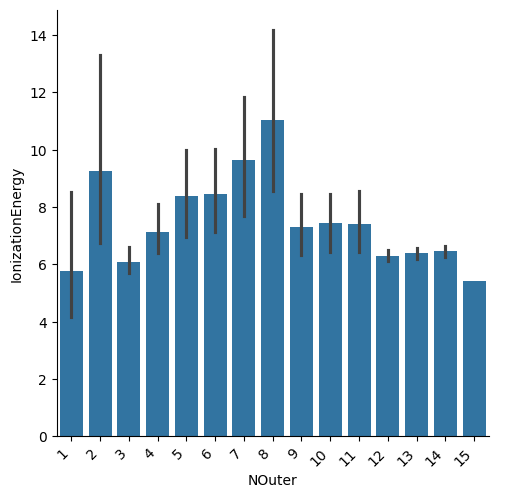

In [19]:
sns.catplot(data=df, x="NOuter", y="IonizationEnergy", kind="bar")
# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

The plot above shows us periodic trends that we learned about in introductory chemistry. The two highest ionization energy categories correspond to elements with 2 valence electrons and 8 valence electrons, representing filled shells.

Seaborn can also allow us to easily create scatter plots to visualize relationships between continuous variables. For example, we can create a scatter plot to show the relationship between ionization energy and atomic radius:

Text(0, 0.5, 'Electronegativity')

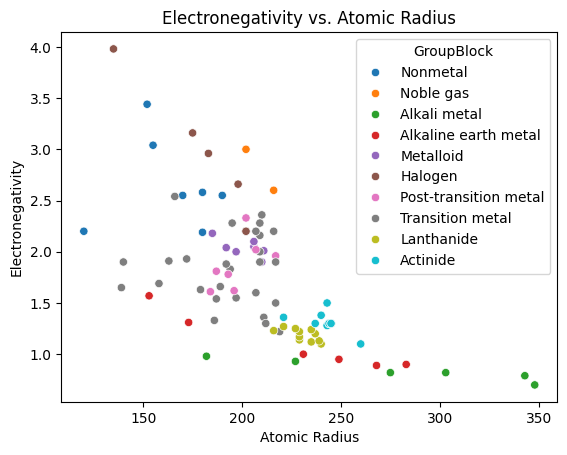

In [20]:
sns.scatterplot(data=df, x="AtomicRadius", y="Electronegativity", hue="GroupBlock")
plt.title('Electronegativity vs. Atomic Radius')
plt.xlabel('Atomic Radius')
plt.ylabel('Electronegativity')

<div class="alert alert-block alert-warning">
<h3>Exercise</h3>

Create a few other categorical plots to observe periodic trends:

1. Electronegativity vs. Group Block as a bar plot.

2. Melting Point vs. Group Block as a bar plot.

3. Ionization Energy vs. Atomic Number as a scatter plot colored by GroupBlock.
   
</div>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Nonmetal'),
  Text(1, 0, 'Noble gas'),
  Text(2, 0, 'Alkali metal'),
  Text(3, 0, 'Alkaline earth metal'),
  Text(4, 0, 'Metalloid'),
  Text(5, 0, 'Halogen'),
  Text(6, 0, 'Post-transition metal'),
  Text(7, 0, 'Transition metal'),
  Text(8, 0, 'Lanthanide'),
  Text(9, 0, 'Actinide')])

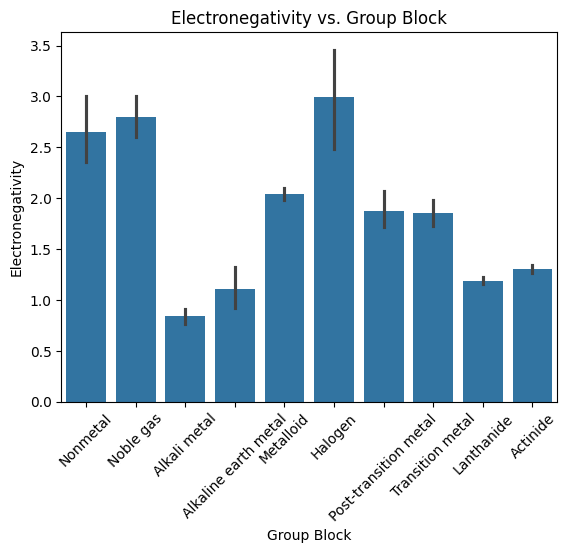

In [21]:
sns.barplot(data=df, x="GroupBlock", y="Electronegativity")             # TO DO: Remember to put the dataframe column title in quotes, but not square brackets
plt.title('Electronegativity vs. Group Block')
plt.xlabel('Group Block')
plt.ylabel('Electronegativity')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Nonmetal'),
  Text(1, 0, 'Noble gas'),
  Text(2, 0, 'Alkali metal'),
  Text(3, 0, 'Alkaline earth metal'),
  Text(4, 0, 'Metalloid'),
  Text(5, 0, 'Halogen'),
  Text(6, 0, 'Post-transition metal'),
  Text(7, 0, 'Transition metal'),
  Text(8, 0, 'Lanthanide'),
  Text(9, 0, 'Actinide')])

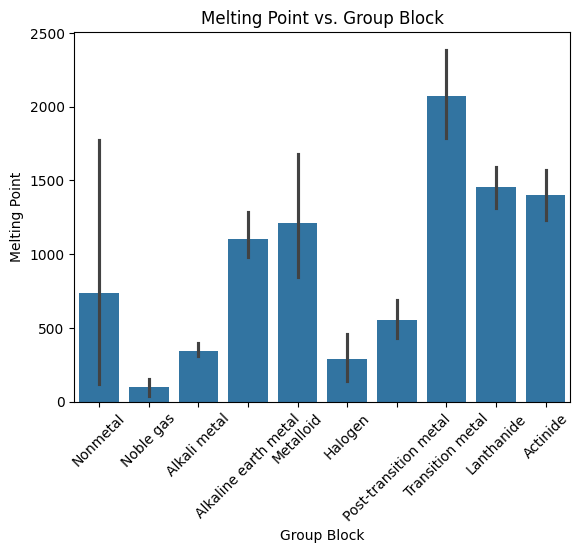

In [22]:
sns.barplot(data=df, x="GroupBlock", y="MeltingPoint")             # TO DO: Remember to put the dataframe column title in quotes, but not square brackets
plt.title('Melting Point vs. Group Block')
plt.xlabel('Group Block')
plt.ylabel('Melting Point')
plt.xticks(rotation=45)

Text(0, 0.5, 'Melting Point')

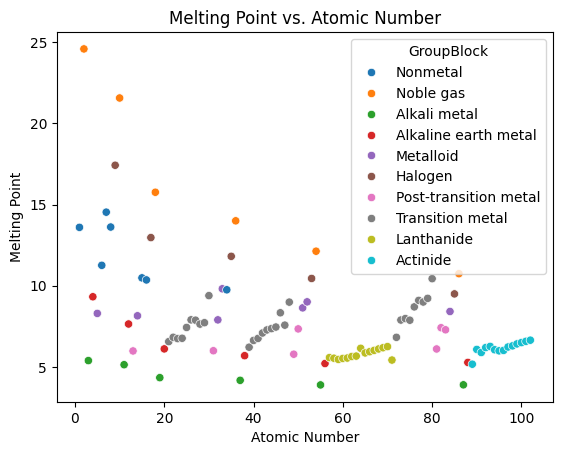

In [23]:
sns.scatterplot(data=df, x="AtomicNumber", y="IonizationEnergy", hue="GroupBlock")             # TO DO: Remember to put the dataframe column title in quotes, but not square brackets
plt.title('Melting Point vs. Atomic Number')
plt.xlabel('Atomic Number')
plt.ylabel('Melting Point')

### Visualizing Correlation

A common way to visualize relationships between different categories of data categories is with a correlation plot.
The correlation matrix provides insights into the relationships between the variables. A correlation value close to 1 indicates a strong positive relationship, while a correlation value close to -1 indicates a strong negative relationship. A correlation value close to 0 indicates no relationship between the features.

In [24]:
# Calculate the correlation matrix
corr = df.corr(numeric_only=True)
corr

,AtomicNumber,AtomicMass,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,MeltingPoint,BoilingPoint,Density,MeltingPointC,BoilingPointC,NOuter,Default_Valence
AtomicNumber,1.000000,0.999258,-0.333108,0.108260,-0.436061,0.033849,0.186428,0.368187,0.725570,0.186428,0.368187,0.070370,0.070370
AtomicMass,0.999258,1.000000,-0.332860,0.103125,-0.421957,0.035010,0.176436,0.358071,0.720749,0.176436,0.358071,0.063630,0.063630
Electronegativity,-0.333108,-0.332860,1.000000,-0.658565,0.904801,0.712926,-0.118976,-0.288225,-0.085101,-0.118976,-0.288225,0.184604,0.184604
AtomicRadius,0.108260,0.103125,-0.658565,1.000000,-0.641088,-0.317003,0.057317,0.213469,0.187537,0.057317,0.213469,0.091258,0.091258
IonizationEnergy,-0.436061,-0.421957,0.904801,-0.641088,1.000000,0.695265,-0.327232,-0.499358,-0.332260,-0.327232,-0.499358,0.048754,0.048754
ElectronAffinity,0.033849,0.035010,0.712926,-0.317003,0.695265,1.000000,-0.294207,-0.423421,-0.068024,-0.294207,-0.423421,0.447026,0.447026
MeltingPoint,0.186428,0.176436,-0.118976,0.057317,-0.327232,-0.294207,1.000000,0.888202,0.571981,1.000000,0.888202,0.242993,0.242993
BoilingPoint,0.368187,0.358071,-0.288225,0.213469,-0.499358,-0.423421,0.888202,1.000000,0.684276,0.888202,1.000000,0.143610,0.143610
Density,0.725570,0.720749,-0.085101,0.187537,-0.332260,-0.068024,0.571981,0.684276,1.000000,0.571981,0.684276,0.330893,0.330893
MeltingPointC,0.186428,0.176436,-0.118976,0.057317,-0.327232,-0.294207,1.000000,0.888202,0.571981,1.000000,0.888202,0.242993,0.242993


Seaborn can be used to create a heatmap to allow easier examination of the correlation of different variables.

<Axes: >

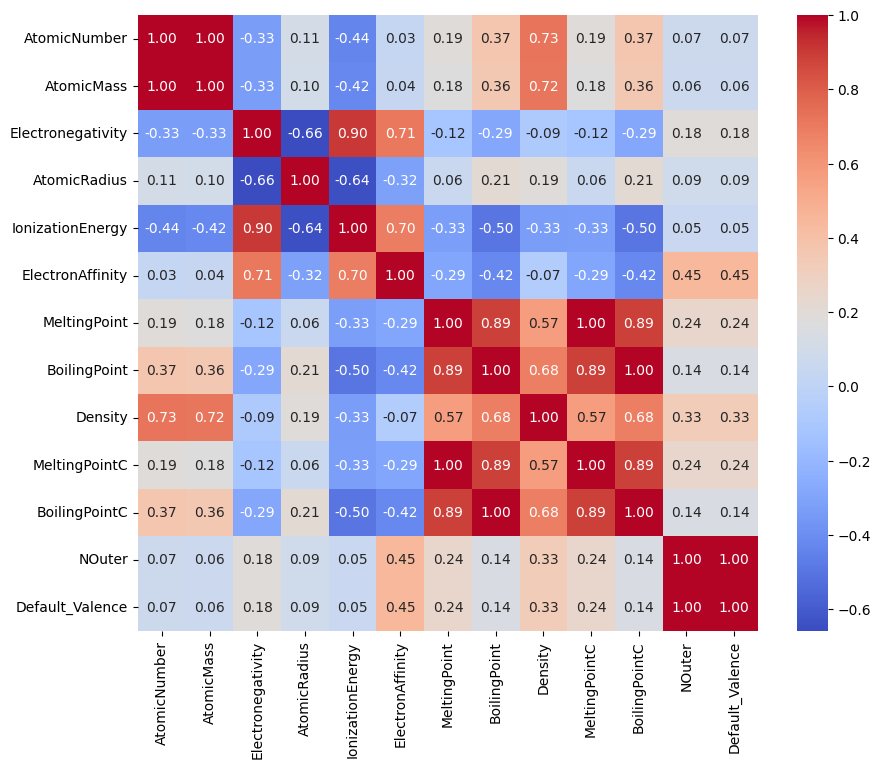

In [25]:
# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

The heatmap uses a "coolwarm" color scheme where red indicates positive correlation and blue indicates negative correlation between variables. Strongly correlated pairs are represented by darker shades of red, while strongly inversely correlated pairs are represented by darker shades of blue.

<div class="alert alert-block alert-warning">
<h3>Final Challenge</h3>

For this challenge, you will retrieve a file called `amino_acids.txt` that contains SMILES for the 20 naturally occurring amino acids. Your task for the final challenge of today is to combine skills and concepts you have learned today to build a dataframe for molecules and write a file. Your goal is to create a comma-separated value file with columns `SMILES`, `num_heavy` (number of heavy atoms), `molecular_weight`, and one other molecular descriptor of your choice for the molecules in the file.

For this task, you will need to complete the following steps. The first three steps are already completed.

1. Retrieve the file amino_acids.txt.
1. Read the data in the file and place the SMILES strings in a list.
1. Create a pandas dataframe, aadf, with the SMILES string as the first column.
1. Use the .apply function to add a new column to aadf that contains an RDKit mol object for each of the SMILES strings.
1. Use the .apply function to then add a column with the number of heavy atoms, a column with the molecular weight and a column with one other molecular descriptor of your choice for each molecule in aadf.
1. Save your file as `data/amino_acids_processed.csv`.


</div>

### Read SMILES from a text file
I will use the ```with open``` command to do this.

In [26]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
from rdkit.Chem import PandasTools

## This cell is provided for the challenge

# Ensure molecules are rendered in the notebook
PandasTools.RenderImagesInAllDataFrames(images=True)

In [27]:
url = ("https://raw.githubusercontent.com/MolSSI-Education/molssicheminfo/refs/heads/master/data/amino_acids.txt")
filename = "amino_acids.txt"
urlretrieve(url, filename)

('amino_acids.txt', <http.client.HTTPMessage at 0x79d619197d10>)

In [28]:
url = ("https://raw.githubusercontent.com/MolSSI-Education/molssicheminfo/refs/heads/master/data/amino_acids.txt")
aa_file = "amino_acids.txt"
urlretrieve(url, aa_file)

with open(aa_file,'r') as outfile:
    aasmiles = outfile.readlines()

aasmiles_strip = []
for smiles in aasmiles:
    smiles = smiles.strip()
    aasmiles_strip.append(smiles)

print(aasmiles_strip)

aadf = pd.DataFrame(
    {'SMILES': aasmiles_strip})

aadf



['C[C@H](N)C(=O)O', 'NC(N)=NCCC[C@H](N)C(=O)O', 'NC(=O)C[C@H](N)C(=O)O', 'N[C@@H](CC(=O)O)C(=O)O', 'N[C@@H](CS)C(=O)O', 'N[C@@H](CCC(=O)O)C(=O)O', 'NC(=O)CC[C@H](N)C(=O)O', 'NCC(=O)O', 'N[C@@H](Cc1cnc[nH]1)C(=O)O', 'CC[C@H](C)[C@H](N)C(=O)O', 'CC(C)C[C@H](N)C(=O)O', 'NCCCC[C@H](N)C(=O)O', 'CSCC[C@H](N)C(=O)O', 'N[C@@H](Cc1ccccc1)C(=O)O', 'O=C(O)[C@@H]1CCCN1', 'N[C@@H](CO)C(=O)O', 'C[C@@H](O)[C@H](N)C(=O)O', 'N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O', 'N[C@@H](Cc1ccc(O)cc1)C(=O)O', 'CC(C)[C@H](N)C(=O)O']


,SMILES
0,C[C@H](N)C(=O)O
1,NC(N)=NCCC[C@H](N)C(=O)O
2,NC(=O)C[C@H](N)C(=O)O
3,N[C@@H](CC(=O)O)C(=O)O
4,N[C@@H](CS)C(=O)O
5,N[C@@H](CCC(=O)O)C(=O)O
6,NC(=O)CC[C@H](N)C(=O)O
7,NCC(=O)O
8,N[C@@H](Cc1cnc[nH]1)C(=O)O
9,CC[C@H](C)[C@H](N)C(=O)O


### Make an RDKit molecule for each SMILES
I did this before. This time, I'll add the SMILES string to the dataframe first, then use the apply function to create the RDKit molecules.

,SMILES,Molecule
0,C[C@H](N)C(=O)O,
1,NC(N)=NCCC[C@H](N)C(=O)O,
2,NC(=O)C[C@H](N)C(=O)O,
3,N[C@@H](CC(=O)O)C(=O)O,
4,N[C@@H](CS)C(=O)O,
5,N[C@@H](CCC(=O)O)C(=O)O,
6,NC(=O)CC[C@H](N)C(=O)O,
7,NCC(=O)O,
8,N[C@@H](Cc1cnc[nH]1)C(=O)O,
9,CC[C@H](C)[C@H](N)C(=O)O,

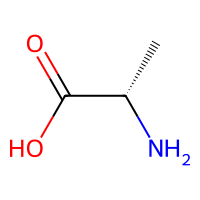
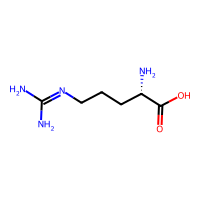
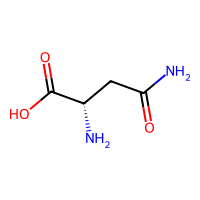
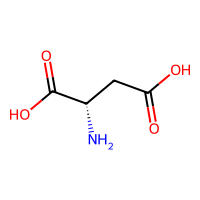
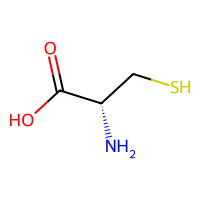
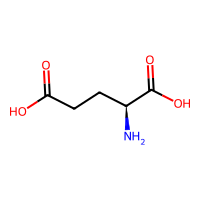
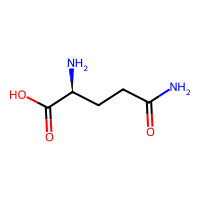
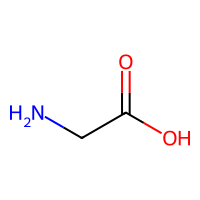
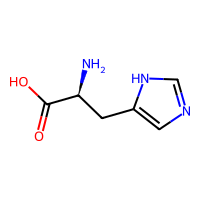
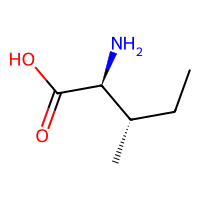
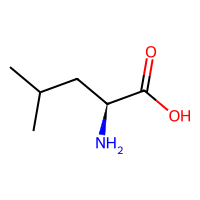
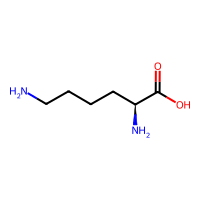
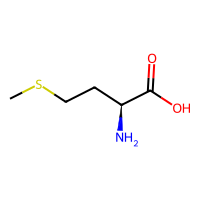
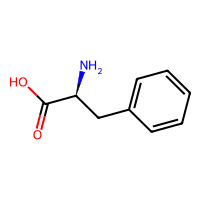
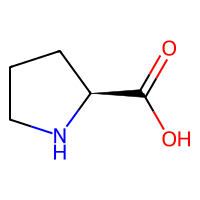
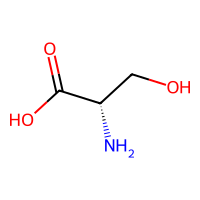
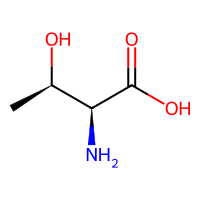
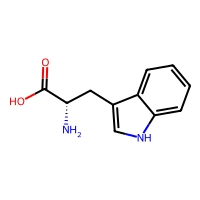
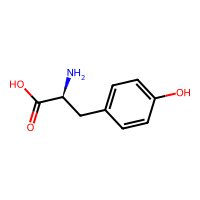
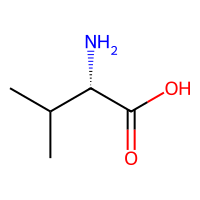

In [29]:
# Create the list of molecules

aadf['Molecule'] = aadf['SMILES'].apply(Chem.MolFromSmiles)
aadf

### Write a file with the data

Generate a .csv file from aadf.

In [30]:
outputfile = ('amino_acids_processed.csv')
aadf.to_csv(outputfile)